# Sample Solution: 4-Agent Fraud Decision (LangGraph + LangChain + OpenAI)

This notebook demonstrates a **simple multi-agent** fraud workflow:

- **Transactions agent**: reviews all transactions for a user (calls tools like “seen before?”, “counterparty history”, “amount outlier”).
- **Profile agent**: reviews the user’s profile / risk context (credit score, account age, 2FA, etc.).
- **Messages agent**: reviews the user’s messages for phishing / social-engineering signals.
- **Meta agent**: combines the three outputs and decides which transaction(s), if any, are fraud.

The goal is to be a *reference implementation* that workshop participants can adapt by editing prompts, tools, and routing.

> Requires: `OPENAI_API_KEY` and installed deps (`langgraph`, `langchain`, `langchain-openai`, `openai`, `python-dotenv`).


In [1]:
# If needed (first time only), install deps:
# %pip install -U langgraph langchain langchain-openai openai python-dotenv pandas

import os
from getpass import getpass

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    pass

if not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("Enter OPENAI_API_KEY: ")

MODEL = os.getenv("OPENAI_MODEL", "gpt-5-mini")
print("Using model:", MODEL)


Using model: gpt-5-mini


## Load data

In [2]:
import pandas as pd

TX_PATH = "../data/train/transactions.csv"
USERS_PATH = "../data/train/users.csv"
MSGS_PATH = "../data/train/messages.csv"

transactions = pd.read_csv(TX_PATH)
users = pd.read_csv(USERS_PATH)
messages = pd.read_csv(MSGS_PATH)

# Parse timestamps (keeps timezone offset in string if present; pandas handles it)
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"], errors="coerce")
messages["timestamp"] = pd.to_datetime(messages["timestamp"], errors="coerce")

print("transactions", transactions.shape)
print("users", users.shape)
print("messages", messages.shape)

display(users.head(3))


transactions (39507, 36)
users (220, 15)
messages (10763, 9)


,user_id,age,employment_status,segment,home_country,home_city,account_open_date,account_age_days,has_2fa,device_count,credit_score,risk_profile,kyc_tier,monthly_income_eur,avg_monthly_spend_eur
0,U00001,35,employed,Mass,AT,Frankfurt,2024-10-14,533,1,2,591,medium,standard,1961.65,1369.86
1,U00002,39,employed,Mass,DE,Cologne,2024-10-26,521,1,2,692,low,standard,2696.65,1865.57
2,U00003,25,employed,Mass,IT,Frankfurt,2025-03-11,385,1,1,694,medium,standard,2336.53,1631.33


## Choose a user

In [3]:
# Pick a user to investigate
# Tip: swap this to any user_id from users.csv
user_id = users["user_id"].iloc[0]
user_id


'U00001'

## Quick preview

In [4]:
tx_user = transactions[transactions["user_id"] == user_id].sort_values("timestamp")
msg_user = messages[messages["user_id"] == user_id].sort_values("timestamp")

print("tx for user", len(tx_user))
print("msgs for user", len(msg_user))

cols = [
    "transaction_id","timestamp","direction","amount_eur","transaction_type",
    "merchant_name","merchant_category","merchant_country","channel",
    "device_id","ip_country","is_international","is_recurring","beneficiary_id",
    "merchant_seen_before","device_seen_before",
]
cols = [c for c in cols if c in tx_user.columns]

display(tx_user[cols].tail(10))


tx for user 139
msgs for user 71


,transaction_id,timestamp,direction,amount_eur,transaction_type,merchant_name,merchant_category,merchant_country,channel,device_id,ip_country,is_international,is_recurring,beneficiary_id,merchant_seen_before,device_seen_before
2829,T0002830,2026-03-26 11:57:31+01:00,debit,28.13,CARD,Supermarkt König,groceries,DE,card,U00001-DEV1,PL,1,0,NaN,1,1
2742,T0002743,2026-03-26 16:14:21+01:00,debit,54.53,TRANSFER,Family Transfer,other,DE,bank_transfer,U00001-DEV1,AT,1,0,B001127,1,1
2755,T0002756,2026-03-26 16:17:03+01:00,debit,28.44,CARD,Supermarkt König,groceries,DE,card,U00001-DEV2,AT,1,0,NaN,1,1
2807,T0002808,2026-03-27 16:31:42+01:00,debit,11.82,CARD,RideNow,transport,DE,card,U00001-DEV1,AT,1,0,NaN,1,1
2805,T0002806,2026-03-28 13:14:28+01:00,debit,52.06,TRANSFER,Marketplace Seller,other,CH,bank_transfer,U00001-DEV1,AT,1,0,B000304,1,1
2731,T0002732,2026-03-29 13:15:23+01:00,debit,4.00,CARD,Café Spreeblick,restaurants,NL,card,U00001-DEV2,AT,1,0,NaN,1,1
2746,T0002747,2026-03-29 15:41:02+01:00,debit,30.89,CARD,Supermarkt König,groceries,DE,card,U00001-DEV1,AT,1,0,NaN,1,1
2786,T0002787,2026-03-29 15:59:57+01:00,debit,7.95,CARD,MusicBox,subscription,CH,card,U00001-DEV1,AT,1,0,NaN,1,1
2780,T0002781,2026-03-30 13:13:50+01:00,debit,18.41,CARD,DiscountMart,groceries,GB,card,U00001-DEV1,AT,1,0,NaN,1,1
2832,T0002833,2026-03-30 17:06:35+01:00,debit,6.00,CARD,HotelNow,travel,ES,card,U00001-DEV1,AT,1,0,NaN,0,1


## LLM

In [12]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model=MODEL)

## Tools (called by agents)

In [13]:
import json
import numpy as np
from langchain_core.tools import tool


def _safe_json(obj) -> str:
    return json.dumps(obj, ensure_ascii=False, default=str)


@tool
def get_user_profile(user_id: str) -> str:
    """Return the user's profile row as JSON."""
    row = users[users["user_id"] == user_id]
    if row.empty:
        return _safe_json({"error": f"unknown user_id {user_id}"})
    return _safe_json(row.iloc[0].to_dict())


@tool
def list_user_transactions(user_id: str, limit: int = 100) -> str:
    """Return up to `limit` transactions for the user (most recent first) as JSON.

    Note: This tool intentionally does NOT return ground-truth labels.
    """
    df = transactions[transactions["user_id"] == user_id].sort_values("timestamp", ascending=False).head(int(limit))
    cols = [
        "transaction_id","timestamp","direction","amount_eur","currency","transaction_type",
        "merchant_name","merchant_category","merchant_country","channel","device_id","ip_country",
        "is_international","is_recurring","recurring_name","beneficiary_id",
        "merchant_seen_before","device_seen_before",
    ]
    cols = [c for c in cols if c in df.columns]
    return _safe_json(df[cols].to_dict(orient="records"))


@tool
def transaction_features(transaction_id: str) -> str:
    """Return key features for a transaction_id as JSON (no labels)."""
    df = transactions[transactions["transaction_id"] == transaction_id]
    if df.empty:
        return _safe_json({"error": f"unknown transaction_id {transaction_id}"})
    row = df.iloc[0]
    out = {
        "transaction_id": row.get("transaction_id"),
        "user_id": row.get("user_id"),
        "timestamp": row.get("timestamp"),
        "direction": row.get("direction"),
        "amount_eur": float(row.get("amount_eur")) if row.get("amount_eur") == row.get("amount_eur") else None,
        "transaction_type": row.get("transaction_type"),
        "merchant_name": row.get("merchant_name"),
        "merchant_category": row.get("merchant_category"),
        "merchant_country": row.get("merchant_country"),
        "ip_country": row.get("ip_country"),
        "device_id": row.get("device_id"),
        "is_international": int(row.get("is_international")) if row.get("is_international") == row.get("is_international") else None,
        "is_recurring": int(row.get("is_recurring")) if row.get("is_recurring") == row.get("is_recurring") else None,
        "beneficiary_id": row.get("beneficiary_id"),
        "merchant_seen_before": int(row.get("merchant_seen_before")) if row.get("merchant_seen_before") == row.get("merchant_seen_before") else None,
        "device_seen_before": int(row.get("device_seen_before")) if row.get("device_seen_before") == row.get("device_seen_before") else None,
    }
    return _safe_json(out)


@tool
def counterparty_history(user_id: str, merchant_name: str = "", beneficiary_id: str = "") -> str:
    """Count how often this user has transacted with the given merchant_name and/or beneficiary_id."""
    df = transactions[transactions["user_id"] == user_id]
    if merchant_name:
        df = df[df["merchant_name"].fillna("") == merchant_name]
    if beneficiary_id and "beneficiary_id" in df.columns:
        df = df[df["beneficiary_id"].fillna("") == beneficiary_id]
    return _safe_json({"count": int(len(df))})


@tool
def amount_outlier_score(user_id: str, amount_eur: float) -> str:
    """Return a simple z-score of amount vs user's historical transaction amounts."""
    df = transactions[(transactions["user_id"] == user_id) & (transactions["amount_eur"].notna())]
    if len(df) < 10:
        return _safe_json({"z": None, "note": "not enough history"})
    vals = df["amount_eur"].astype(float)
    mean = float(vals.mean())
    std = float(vals.std(ddof=0)) or 1.0
    z = (float(amount_eur) - mean) / std
    return _safe_json({"z": float(z), "mean": mean, "std": std})


@tool
def list_user_messages(user_id: str, limit: int = 60) -> str:
    """Return up to `limit` messages for the user (most recent first) as JSON."""
    df = messages[messages["user_id"] == user_id].sort_values("timestamp", ascending=False).head(int(limit))
    cols = ["message_id","timestamp","channel","sender","message_text"]
    cols = [c for c in cols if c in df.columns]
    return _safe_json(df[cols].to_dict(orient="records"))


@tool
def phishing_keyword_scan(user_id: str) -> str:
    """Heuristic scan for common phishing/urgency words in the user's messages."""
    df = messages[messages["user_id"] == user_id]
    if df.empty:
        return _safe_json({"count": 0, "examples": []})
    keywords = ["urgent", "immediately", "verify", "suspend", "locked", "password", "otp", "code", "link", "refund"]

    def score(text: str) -> int:
        t = (text or "").lower()
        return sum(1 for k in keywords if k in t)

    scored = df.assign(_score=df["message_text"].fillna("").map(score))
    hits = scored[scored["_score"] >= 2].sort_values("_score", ascending=False).head(5)
    examples = [
        {"sender": r["sender"], "message_text": r["message_text"], "score": int(r["_score"])}
        for _, r in hits.iterrows()
    ]
    return _safe_json({"count": int((scored["_score"] >= 2).sum()), "examples": examples})


## Tool-calling agent runner

In [14]:
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage


def _tool_call_parts(call):
    """Normalize tool call object/dict across LangChain versions."""
    if isinstance(call, dict):
        return call.get("id"), call.get("name"), call.get("args", {})
    return getattr(call, "id", None), getattr(call, "name", None), getattr(call, "args", {})


def run_tool_calling_agent(*, system_prompt: str, user_prompt: str, tools: list, max_steps: int = 8) -> str:
    """Run a single agent that can call tools; returns the final assistant text."""

    tool_map = {t.name: t for t in tools}
    bound = llm.bind_tools(tools)

    messages = [SystemMessage(content=system_prompt), HumanMessage(content=user_prompt)]

    for _ in range(max_steps):
        ai = bound.invoke(messages)
        messages.append(ai)

        tool_calls = getattr(ai, "tool_calls", None) or []
        if not tool_calls:
            return ai.content

        for call in tool_calls:
            call_id, name, args = _tool_call_parts(call)
            if not name or name not in tool_map:
                messages.append(ToolMessage(content=f"[ERROR] unknown tool: {name}", tool_call_id=str(call_id or name)))
                continue

            result = tool_map[name].invoke(args)
            messages.append(ToolMessage(content=str(result), tool_call_id=str(call_id or name)))

    return "[ERROR] agent exceeded max_steps without producing a final answer"


## Agent prompts (edit these)

In [20]:
TRANSACTIONS_AGENT_PROMPT = """
You are the Transactions Agent.

Goal: Identify suspicious transaction(s) for ONE user. Use the tools to inspect transactions and compute evidence.

Rules:
- Use tools instead of guessing (list transactions, fetch features, check counterparty history, compute amount outlier z-score).
- Focus on *debits* / money leaving the user, but you may flag credits if clearly suspicious.
- Output STRICT JSON with keys:
  - "suspicious_transaction_ids": list of transaction_id strings (can be empty)
  - "evidence": dict mapping transaction_id -> list of short bullet-like strings
  - "summary": 2-4 sentences
""".strip()

PROFILE_AGENT_PROMPT = """
You are the Profile Agent.

Goal: Provide user-risk context that could influence fraud decisions.

Rules:
- Use get_user_profile.
- Output STRICT JSON with keys:
  - "risk_level": one of ["low","medium","high"]
  - "risk_factors": list of short strings
  - "summary": 2-4 sentences
""".strip()

MESSAGES_AGENT_PROMPT = """
You are the Messages Agent.

Goal: Look for phishing / social-engineering signals in the user's messages that could correlate with fraud.

Rules:
- Use list_user_messages and phishing_keyword_scan.
- Output STRICT JSON with keys:
  - "phishing_signal": one of ["none","weak","strong"]
  - "notable_senders": list of strings
  - "evidence": list of short strings
  - "summary": 2-4 sentences
""".strip()

META_AGENT_PROMPT = """
You are the Meta Agent (final decision maker).

Input: JSON outputs from the Transactions, Profile, and Messages agents.

Goal: Decide which transactions (if any) are fraud.

Rules:
- Prefer precision over recall (only flag fraud when evidence is convincing).
- If the Transactions agent proposes candidates, validate each using transaction_features and amount_outlier_score.
- Output STRICT JSON with keys:
  - "fraud_transaction_ids": list of transaction_id strings (can be empty)
  - "rationale": dict mapping transaction_id -> 2-5 short strings
  - "overall_summary": 2-4 sentences
  - Make sure that the transactions are actually fraud and not just unusual, based on the evidence and tool checks.
  - the amount of fraud transactions are very less as compared to non-fraud transactions, so be conservative in flagging fraud.
""".strip()


## LangGraph (3 sub-agents + meta agent)

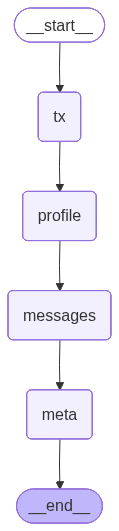

In [21]:
from typing import TypedDict

from langgraph.graph import START, END, StateGraph

TOOLS_TX = [list_user_transactions, transaction_features, counterparty_history, amount_outlier_score]
TOOLS_PROFILE = [get_user_profile]
TOOLS_MSG = [list_user_messages, phishing_keyword_scan]
TOOLS_META = [transaction_features, amount_outlier_score, counterparty_history, get_user_profile, phishing_keyword_scan]


class FraudState(TypedDict, total=False):
    user_id: str
    tx_out: str
    profile_out: str
    msg_out: str
    final_out: str


def tx_node(state: FraudState) -> FraudState:
    user_id = state["user_id"]
    out = run_tool_calling_agent(
        system_prompt=TRANSACTIONS_AGENT_PROMPT,
        user_prompt=f"Investigate user_id={user_id}.",
        tools=TOOLS_TX,
    )
    return {"tx_out": out}


def profile_node(state: FraudState) -> FraudState:
    user_id = state["user_id"]
    out = run_tool_calling_agent(
        system_prompt=PROFILE_AGENT_PROMPT,
        user_prompt=f"Analyze profile for user_id={user_id}.",
        tools=TOOLS_PROFILE,
    )
    return {"profile_out": out}


def msg_node(state: FraudState) -> FraudState:
    user_id = state["user_id"]
    out = run_tool_calling_agent(
        system_prompt=MESSAGES_AGENT_PROMPT,
        user_prompt=f"Analyze messages for user_id={user_id}.",
        tools=TOOLS_MSG,
    )
    return {"msg_out": out}


def meta_node(state: FraudState) -> FraudState:
    user_id = state["user_id"]
    joined = {
        "user_id": user_id,
        "transactions_agent": state.get("tx_out", ""),
        "profile_agent": state.get("profile_out", ""),
        "messages_agent": state.get("msg_out", ""),
    }
    out = run_tool_calling_agent(
        system_prompt=META_AGENT_PROMPT,
        user_prompt="Combine these agent outputs and decide fraud." + _safe_json(joined),
        tools=TOOLS_META,
    )
    return {"final_out": out}


g = StateGraph(FraudState)
g.add_node("tx", tx_node)
g.add_node("profile", profile_node)
g.add_node("messages", msg_node)
g.add_node("meta", meta_node)

g.add_edge(START, "tx")
g.add_edge("tx", "profile")
g.add_edge("profile", "messages")
g.add_edge("messages", "meta")
g.add_edge("meta", END)

fraud_app = g.compile()
fraud_app


## Run the multi-agent workflow

In [22]:
result = fraud_app.invoke({"user_id": user_id})

print("=== Transactions agent ===")
print(result["tx_out"]) 
print("=== Profile agent ===")
print(result["profile_out"]) 
print("=== Messages agent ===")
print(result["msg_out"]) 
print("=== Meta agent (FINAL) ===")
print(result["final_out"]) 

=== Transactions agent ===
{
  "suspicious_transaction_ids": [
    "T0002802",
    "T0002832",
    "T0002738",
    "T0002798"
  ],
  "evidence": {
    "T0002802": [
      "amount €619.86 — one of the largest card debits in the recent history",
      "amount outlier z = 1.5586 (mean €123.67, std €318.35)",
      "merchant SmartGadgets (electronics) — international merchant_country=CH while ip_country=AT",
      "counterparty history: SmartGadgets count = 4 (multiple interactions) but this is a high-value card charge",
      "device_id U00001-DEV2 used (different device than some other high-value purchases)"
    ],
    "T0002832": [
      "amount €359.19 — large single card purchase",
      "amount outlier z = 0.7398 (mean €123.67, std €318.35)",
      "merchant TechWorld Online (electronics) — merchant_seen_before = 0 (counterparty_history count = 1, first/rare merchant)",
      "card transaction is international (merchant_country=DE, ip_country=AT)"
    ],
    "T0002738": [
      "amou

## Evaluate vs labels (optional)

In [ ]:
final = json.loads(result["final_out"])
flagged = set(final.get("fraud_transaction_ids", []))

truth_df = transactions[transactions["user_id"] == user_id]
truth_fraud = set(truth_df[truth_df["is_fraud"] == 1]["transaction_id"].tolist())

print("Flagged:", sorted(flagged)[:20], "..." if len(flagged) > 20 else "")
print("Truth fraud:", sorted(truth_fraud)[:20], "..." if len(truth_fraud) > 20 else "")

print("TP", len(flagged & truth_fraud))
print("FP", len(flagged - truth_fraud))
print("FN", len(truth_fraud - flagged))